# Classification

## Overview

This notebook trains classical machine learning models for furniture sketch classification.

The previous notebook extracted HOG features from Canny sketch images. These features are now used as numerical input for classification models.

The main goal is to predict the furniture category from a sketch-like image representation. The first baseline model is Support Vector Machine (SVM), followed by additional classical machine learning models for comparison.

The classification task uses five furniture classes:

- bed
- chair
- dresser
- sofa
- table

The predefined train / validation / test split from the dataset is preserved throughout the experiment.

## Setup and Imports

In [11]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier

sys.path.append("..")

%reload_ext autoreload
%autoreload 2

from src import utils

pd.set_option("display.max_columns", None)
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["figure.dpi"] = 100

print("Libraries loaded successfully")

Libraries loaded successfully


## Load Feature Arrays

The feature arrays created in Notebook 03 are loaded here.

`X_hog` contains the HOG feature matrix, where each row represents one sketch image and each column represents one HOG feature. The label array `y` contains the furniture class name for each image. The `splits` array preserves the predefined train, validation, and test split assignment. 

In [2]:
features_dir = utils.DATA_DIR / "features"

X_hog = np.load(features_dir / "X_hog.npy")
y = np.load(features_dir / "y.npy", allow_pickle=True)
splits = np.load(features_dir / "splits.npy", allow_pickle=True)
relative_paths = np.load(features_dir / "relative_paths.npy", allow_pickle=True)

print(f"X_hog shape: {X_hog.shape}")
print(f"y shape: {y.shape}")
print(f"splits shape: {splits.shape}")
print(f"relative_paths shape: {relative_paths.shape}")

X_hog shape: (2500, 8100)
y shape: (2500,)
splits shape: (2500,)
relative_paths shape: (2500,)


In [3]:
print(f"Feature matrix dtype: {X_hog.dtype}")
print(f"Classes: {sorted(np.unique(y))}")
print(f"Split values: {sorted(np.unique(splits))}")

Feature matrix dtype: float64
Classes: [np.str_('bed'), np.str_('chair'), np.str_('dresser'), np.str_('sofa'), np.str_('table')]
Split values: [np.str_('test'), np.str_('train'), np.str_('val')]


### Observation

The feature arrays from Notebook 03 were loaded successfully. The HOG feature matrix has shape (**2500, 8100**), matching **2,500** sketches with **8,100** features each. The label, split, and relative-path arrays are aligned with the feature matrix at **2,500** entries each.

The feature matrix is stored as `float64`, the five furniture classes are present, and all three split values (`train`, `val`, `test`) are available. The data is intact and ready to be divided into training, validation, and test matrices.

## Create Train / Validation / Test Matrices

The predefined split information is used to create separate train, validation, and test matrices.

The training set is used to fit the model. The validation set is used to evaluate model performance during development and compare models. The test set is kept separate for final evaluation.

In [4]:
train_mask = splits == "train"
val_mask = splits == "val"
test_mask = splits == "test"

X_train, y_train = X_hog[train_mask], y[train_mask]
X_val, y_val = X_hog[val_mask], y[val_mask]
X_test, y_test = X_hog[test_mask], y[test_mask]

print(f"Train: {X_train.shape[0]} samples")
print(f"Val:   {X_val.shape[0]} samples")
print(f"Test:  {X_test.shape[0]} samples")

print(f"\nTrain class distribution:")
print(pd.Series(y_train).value_counts().sort_index())

Train: 1750 samples
Val:   375 samples
Test:  375 samples

Train class distribution:
bed        350
chair      350
dresser    350
sofa       350
table      350
Name: count, dtype: int64


In [5]:
print("Validation class distribution:")
print(pd.Series(y_val).value_counts().sort_index())

print("\nTest class distribution:")
print(pd.Series(y_test).value_counts().sort_index())

Validation class distribution:
bed        75
chair      75
dresser    75
sofa       75
table      75
Name: count, dtype: int64

Test class distribution:
bed        75
chair      75
dresser    75
sofa       75
table      75
Name: count, dtype: int64


The dataset was split successfully into training, validation, and test subsets. The prototype dataset remains balanced across all five furniture classes, with **350** training samples, **75** validation samples, and **75** test samples per class.

This balance is useful because accuracy and macro F1-score can be interpreted more clearly when each class has the same number of samples in each split.

## Evaluation Metrics

Accuracy and macro F1-score are used as the main evaluation metrics.

Accuracy measures the overall proportion of correctly classified images.

Macro F1-score calculates the F1-score independently for each class and then averages the scores equally across all classes. This is useful for multi-class classification because each furniture category contributes equally to the final score.

In [7]:
def evaluate_classifier(model, X_eval, y_eval, model_name="Model"):
    """
    Evaluate a trained classifier using accuracy, macro F1-score,
    and a full classification report.
    """
    y_pred = model.predict(X_eval)

    accuracy = accuracy_score(y_eval, y_pred)
    macro_f1 = f1_score(y_eval, y_pred, average="macro")

    print(f"{model_name} evaluation")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Macro F1-score: {macro_f1:.4f}")
    print("\nClassification report:")
    print(classification_report(y_eval, y_pred, zero_division=0))

    return {
        "model": model_name,
        "accuracy": accuracy,
        "macro_f1": macro_f1,
        "y_pred": y_pred,
    }

## Baseline Model: SVM

Support Vector Machine is used as the first baseline classifier.

SVM is a suitable starting model because HOG features are high-dimensional numerical descriptors, and SVMs often perform well with this type of feature representation.

A `StandardScaler` is used before the classifier because SVM models are sensitive to feature scale.

In [8]:
%%time

svm_model = Pipeline([
    ("scaler", StandardScaler()),
    ("classifier", SVC(
        kernel="rbf",
        C=1.0,
        gamma="scale",
        random_state=utils.RANDOM_STATE
    )),
])

svm_model.fit(X_train, y_train)

print("SVM model trained successfully")

SVM model trained successfully
CPU times: total: 1min 24s
Wall time: 22.9 s


In [9]:
svm_val_results = evaluate_classifier(
    svm_model,
    X_val,
    y_val,
    model_name="SVM validation"
)

SVM validation evaluation
Accuracy: 0.7653
Macro F1-score: 0.7689

Classification report:
              precision    recall  f1-score   support

         bed       0.83      0.67      0.74        75
       chair       0.59      0.85      0.70        75
     dresser       0.92      0.81      0.87        75
        sofa       0.76      0.81      0.79        75
       table       0.85      0.68      0.76        75

    accuracy                           0.77       375
   macro avg       0.79      0.77      0.77       375
weighted avg       0.79      0.77      0.77       375



### Observation

The first SVM baseline achieved a validation accuracy of **0.7653** and a macro F1-score of **0.7689**.

This result confirms that the pipeline is working: HOG features extracted from Canny sketch images contain enough shape information for classical machine learning classification.

The strongest class is `dresser`, with an F1-score of **0.87**. This is likely because dressers often contain distinctive rectangular outlines and drawer structures. The weakest class is `chair`, with an F1-score of **0.70**. Chair precision is lower than recall, meaning that the model often predicts other furniture sketches as chairs.

Overall, the SVM baseline provides a solid first result for the prototype dataset.

## SVM Confusion Matrix

The confusion matrix shows which furniture classes are predicted correctly and which classes are confused with each other.

Rows represent the true labels, and columns represent the predicted labels.

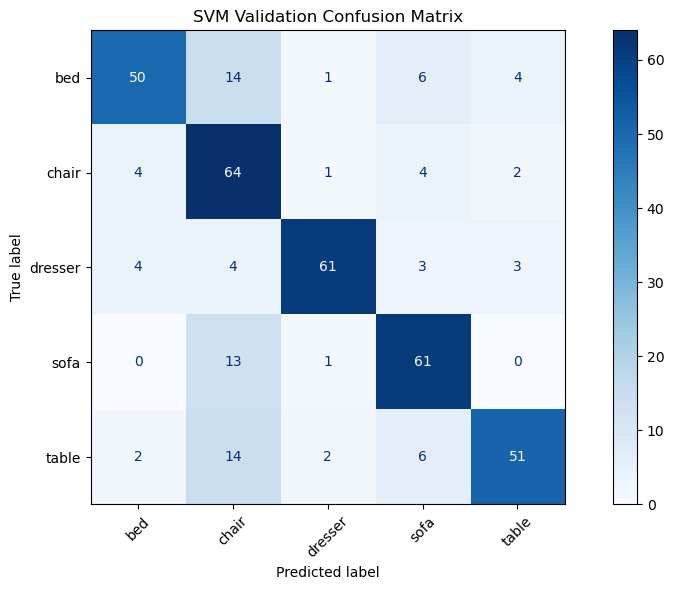

Figure saved to: C:\Users\Vanya\PycharmProjects\PythonProject\SoftUni-Studies\Furniture-Sketch-Classifier\outputs\figures\svm_validation_confusion_matrix.png


In [10]:
labels = sorted(np.unique(y))

cm = confusion_matrix(
    y_val,
    svm_val_results["y_pred"],
    labels=labels
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=labels
)

disp.plot(cmap="Blues", xticks_rotation=45)

plt.title("SVM Validation Confusion Matrix")
plt.tight_layout()

fig_path = utils.FIGURES_DIR / "svm_validation_confusion_matrix.png"
plt.savefig(fig_path, dpi=150, bbox_inches="tight")
plt.show()

print(f"Figure saved to: {fig_path}")

### Observation

The confusion matrix confirms the validation results from the classification report.

The model correctly classifies many examples from each class. `Dresser` and `sofa` show strong diagonal values, meaning most of their samples are classified correctly. The distinctive drawer-grid structure of dressers makes them especially separable.

The main confusion pattern is that several classes are sometimes predicted as `chair` (14 beds, 13 sofas, 14 tables, and 4 dressers). This matches the classification report, where `chair` had high recall but low precision. The most frequent specific error is `sofa` predicted as `chair`, which is intuitive: sofas and chairs share similar edge structures such as a seat, back, arms, and legs, and these become difficult to separate from contour information alone.

The `bed` class shows more scattered misclassifications, spread across chair, sofa, and table. This is consistent with the intra-class variation identified in Notebook 01, where the `bed` category contains several visually different subtypes such as platform, canopy, daybed, and bunk beds.

Overall, the errors are concentrated and structurally explainable rather than random, which suggests the SVM baseline is learning genuine shape patterns. This provides a solid first result for the sketch classification pipeline.

## Additional Classical ML Models

After the SVM baseline, additional classical machine learning models are trained on the same HOG feature representation.

The goal is to compare different types of classifiers:

- Logistic Regression as a linear model;
- KNN (K-Nearest Neighbors) as a distance-based model;
- Random Forest as an ensemble tree-based model;
- SVM as the baseline margin-based model.

Comparing different model families is useful because each model makes different assumptions about how the data is structured. If several model types reach similar performance, the result is more likely to reflect genuine structure in the HOG features rather than the bias of a single algorithm.

All models are evaluated on the validation set using the same metrics: accuracy and macro F1-score.

In [12]:
models = {
    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("classifier", LogisticRegression(
            max_iter=1000,
            random_state=utils.RANDOM_STATE
        )),
    ]),

    "KNN": Pipeline([
        ("scaler", StandardScaler()),
        ("classifier", KNeighborsClassifier(n_neighbors=5)),
    ]),

    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        random_state=utils.RANDOM_STATE,
        n_jobs=-1
    ),

    "SVM": svm_model,
}

In [13]:
validation_results = []

for model_name, model in models.items():
    print("=" * 60)
    print(model_name)

    if model_name != "SVM":
        model.fit(X_train, y_train)

    result = evaluate_classifier(
        model,
        X_val,
        y_val,
        model_name=f"{model_name} validation"
    )

    validation_results.append({
        "model": model_name,
        "accuracy": result["accuracy"],
        "macro_f1": result["macro_f1"],
    })

Logistic Regression
Logistic Regression validation evaluation
Accuracy: 0.7867
Macro F1-score: 0.7877

Classification report:
              precision    recall  f1-score   support

         bed       0.82      0.75      0.78        75
       chair       0.77      0.80      0.78        75
     dresser       0.90      0.83      0.86        75
        sofa       0.76      0.80      0.78        75
       table       0.70      0.76      0.73        75

    accuracy                           0.79       375
   macro avg       0.79      0.79      0.79       375
weighted avg       0.79      0.79      0.79       375

KNN
KNN validation evaluation
Accuracy: 0.4747
Macro F1-score: 0.4737

Classification report:
              precision    recall  f1-score   support

         bed       0.76      0.39      0.51        75
       chair       0.85      0.37      0.52        75
     dresser       0.30      0.99      0.46        75
        sofa       0.83      0.20      0.32        75
       table       0

***Note*: the results are already interesting:**

 - Logistic Regression: accuracy 0.7867, macro F1 0.7877
 - Random Forest: accuracy 0.7813, macro F1 0.7817
 - SVM: accuracy 0.7653, macro F1 0.7689
 - KNN: accuracy 0.4773, macro F1 0.4737

## Model Comparison

The validation results are summarized in a comparison table.

The models are compared using accuracy and macro F1-score. Macro F1-score is used as the main selection metric because it gives equal importance to all five furniture classes.

In [14]:
results_df = pd.DataFrame(validation_results).sort_values(
    by="macro_f1",
    ascending=False
)

results_df

,model,accuracy,macro_f1
0,Logistic Regression,0.786667,0.787726
2,Random Forest,0.781333,0.781674
3,SVM,0.765333,0.768859
1,KNN,0.474667,0.473720


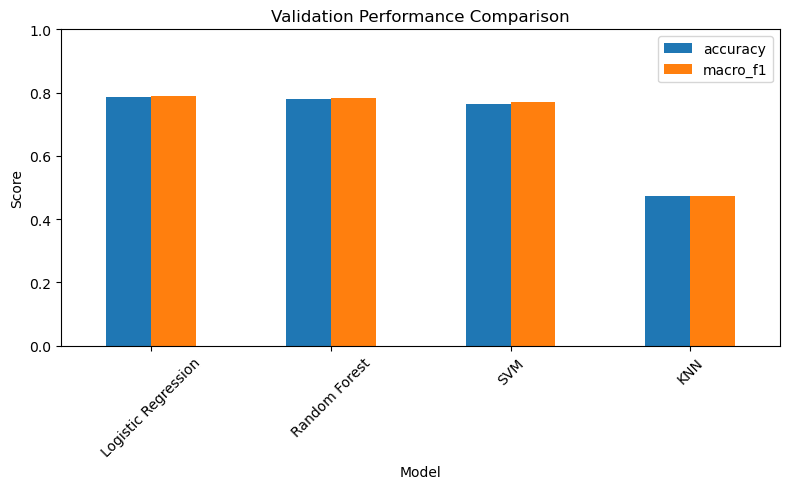

Figure saved to: C:\Users\Vanya\PycharmProjects\PythonProject\SoftUni-Studies\Furniture-Sketch-Classifier\outputs\figures\model_comparison_validation.png


In [15]:
fig, ax = plt.subplots(figsize=(8, 5))

results_df.set_index("model")[["accuracy", "macro_f1"]].plot(
    kind="bar",
    ax=ax
)

ax.set_title("Validation Performance Comparison")
ax.set_xlabel("Model")
ax.set_ylabel("Score")
ax.set_ylim(0, 1)
ax.tick_params(axis="x", rotation=45)

plt.tight_layout()

fig_path = utils.FIGURES_DIR / "model_comparison_validation.png"
plt.savefig(fig_path, dpi=150, bbox_inches="tight")
plt.show()

print(f"Figure saved to: {fig_path}")

### Observation

The comparison shows that three of the four models reach similar validation performance, with macro F1-scores between **0.77** and **0.79**. Logistic Regression performs best, with a macro F1-score of **0.7877**, followed closely by Random Forest (**0.7817**) and the SVM baseline (**0.7689**).

The fact that three different model families, linear Logistic Regression, ensemble tree-based Random Forest, and margin-based SVM, reach comparable results suggests that the performance reflects genuine structure in the HOG features rather than the bias of a single algorithm.

Notably, the linear Logistic Regression model matches and slightly exceeds the non-linear RBF SVM. This indicates that the furniture classes are largely separable in the high-dimensional HOG feature space, where a linear decision boundary is often sufficient. The simpler model is therefore both slightly more accurate and faster to train on this representation.

KNN performs substantially worse, with a macro F1-score of **0.4737**. This is consistent with the curse of dimensionality: in an **8,100-dimensional** feature space, distances between points become less meaningful, which weakens distance-based classification. Its per-class results confirm this, with `dresser` reaching **0.99 recall** but only **0.30 precision**, meaning many samples from other classes are incorrectly assigned to `dresser`.

Overall, Logistic Regression is selected as the best-performing model on the validation set and is carried forward to the final test evaluation.

## Best Model Selection

The best model is selected using validation macro F1-score.

Macro F1-score is used because it gives equal importance to all five furniture classes. This is appropriate for the balanced prototype dataset and helps compare model performance beyond overall accuracy.

In [16]:
best_model_name = results_df.iloc[0]["model"]
best_model = models[best_model_name]

print(f"Best model based on validation macro F1-score: {best_model_name}")
print(f"Validation macro F1-score: {results_df.iloc[0]['macro_f1']:.4f}")
print(f"Validation accuracy: {results_df.iloc[0]['accuracy']:.4f}")

Best model based on validation macro F1-score: Logistic Regression
Validation macro F1-score: 0.7877
Validation accuracy: 0.7867


### Observation

Logistic Regression is selected as the best model, with the highest validation macro F1-score of **0.7877**.

It should be noted that the top three models are separated by a small margin (macro F1 **0.7689** to **0.7877**), so the selection is not decisive. Logistic Regression is preferred not only for its slightly higher score but also because it is the simplest and fastest of the three strong models, which is an advantage when performance is otherwise comparable.

The selected model is now evaluated once on the held-out test set, which has not been used during training or model selection.

## Final Test Evaluation

The selected Logistic Regression model is evaluated on the held-out test set.

The test set was not used for training or model selection. It provides the final estimate of how well the selected model generalizes to unseen sketch images.

In [17]:
test_results = evaluate_classifier(
    best_model,
    X_test,
    y_test,
    model_name=f"{best_model_name} test"
)

Logistic Regression test evaluation
Accuracy: 0.7867
Macro F1-score: 0.7861

Classification report:
              precision    recall  f1-score   support

         bed       0.79      0.72      0.76        75
       chair       0.82      0.75      0.78        75
     dresser       0.76      0.83      0.79        75
        sofa       0.81      0.85      0.83        75
       table       0.76      0.79      0.77        75

    accuracy                           0.79       375
   macro avg       0.79      0.79      0.79       375
weighted avg       0.79      0.79      0.79       375



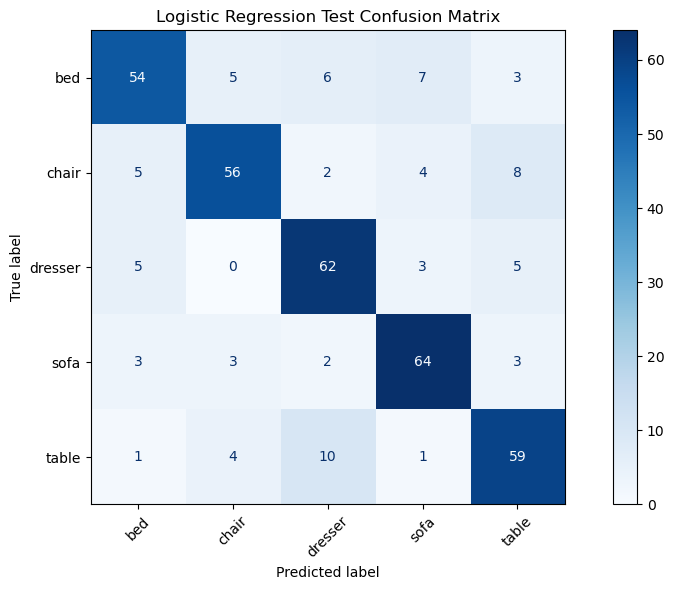

Figure saved to: C:\Users\Vanya\PycharmProjects\PythonProject\SoftUni-Studies\Furniture-Sketch-Classifier\outputs\figures\best_model_test_confusion_matrix.png


In [18]:
labels = sorted(np.unique(y))

cm_test = confusion_matrix(
    y_test,
    test_results["y_pred"],
    labels=labels
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_test,
    display_labels=labels
)

disp.plot(cmap="Blues", xticks_rotation=45)

plt.title(f"{best_model_name} Test Confusion Matrix")
plt.tight_layout()

fig_path = utils.FIGURES_DIR / "best_model_test_confusion_matrix.png"
plt.savefig(fig_path, dpi=150, bbox_inches="tight")
plt.show()

print(f"Figure saved to: {fig_path}")

### Observation

On the held-out test set, the Logistic Regression model achieves an accuracy of **0.7867** and a macro F1-score of **0.7861**. This is almost identical to its validation macro F1-score of **0.7877**, indicating that the model generalizes well to unseen sketches with no significant overfitting.

Performance is balanced across classes, with diagonal values ranging from **54** for `bed` to **64** for `sofa` out of **75** samples per class. The strongest classes are `sofa` and `dresser`, while `bed` remains one of the more difficult classes. This is consistent with the intra-class variation in bed subtypes identified in Notebook 01.

The most frequent error is `table` predicted as `dresser` (**10 cases**). This is an explainable confusion, since both categories can contain rectangular surfaces and supporting leg or base structures that produce similar edge outlines. Compared with the SVM baseline, where the main confusion was `sofa` predicted as `chair`, the dominant error has shifted. This suggests that while overall difficulty is similar across models, the specific class confusions depend partly on the classifier.

Overall, the test result confirms that HOG features extracted from Canny sketches support reliable five-class furniture classification, with a final macro F1-score of approximately **0.79**.

## Save Results

The model comparison results and final test predictions are saved for later analysis.

The saved files will be used in Notebook 05 for result analysis and wrong prediction inspection.

In [19]:
tables_dir = utils.OUTPUTS_DIR / "tables"
tables_dir.mkdir(parents=True, exist_ok=True)

results_path = tables_dir / "validation_model_comparison.csv"
results_df.to_csv(results_path, index=False)

print(f"Validation model comparison saved to: {results_path}")

Validation model comparison saved to: C:\Users\Vanya\PycharmProjects\PythonProject\SoftUni-Studies\Furniture-Sketch-Classifier\outputs\tables\validation_model_comparison.csv


In [21]:
relative_paths_test = relative_paths[test_mask]

In [22]:
test_predictions_df = pd.DataFrame({
    "relative_path": relative_paths_test,
    "true_label": y_test,
    "predicted_label": test_results["y_pred"],
    "correct": y_test == test_results["y_pred"],
})

predictions_path = tables_dir / "test_predictions.csv"
test_predictions_df.to_csv(predictions_path, index=False)

print(f"Test predictions saved to: {predictions_path}")
test_predictions_df.head()

Test predictions saved to: C:\Users\Vanya\PycharmProjects\PythonProject\SoftUni-Studies\Furniture-Sketch-Classifier\outputs\tables\test_predictions.csv


,relative_path,true_label,predicted_label,correct
0,houzz/dressers/Transitional/1623transitional-d...,dresser,dresser,True
1,houzz/sofas/Contemporary/189contemporary-sofas...,sofa,sofa,True
2,houzz/tables/Modern/10919modern-coffee-tables.jpg,table,chair,False
3,houzz/tables/Modern/8865modern-side-tables-and...,table,table,True
4,houzz/chairs/Contemporary/2685contemporary-rec...,chair,chair,True


### Observation

The validation model comparison table and final test predictions were saved successfully.

The `test_predictions.csv` file stores the relative image path, true label, predicted label, and correctness flag for each test sample. This file will be used in Notebook 05 to inspect correct and incorrect predictions and to analyze typical classification errors.

## Error Analysis Preparation

The saved test prediction file provides the input for detailed error analysis in Notebook 05.

Incorrect predictions can be selected using the `correct == False` flag and connected back to the original furniture images through the saved `relative_path` column.

In [23]:
n_wrong = (~test_predictions_df["correct"]).sum()

print(f"Total test predictions: {len(test_predictions_df)}")
print(f"Correct predictions: {test_predictions_df['correct'].sum()}")
print(f"Incorrect predictions to analyze in Notebook 05: {n_wrong}")

Total test predictions: 375
Correct predictions: 295
Incorrect predictions to analyze in Notebook 05: 80


The test set contains **80** incorrect predictions. These cases will be inspected in Notebook 05 to understand typical failure patterns and visually similar furniture categories.

## Summary and Next Steps

This notebook trained and evaluated classical machine learning models for furniture sketch classification using HOG features extracted from Canny sketch images.

Main outcomes:

- The HOG feature arrays from Notebook 03 were loaded successfully.
- The predefined train / validation / test split was preserved.
- The prototype dataset remained balanced across all five furniture classes.
- An SVM baseline was trained and evaluated.
- Additional classical ML models were compared: Logistic Regression, KNN, and Random Forest.
- Logistic Regression achieved the best validation macro F1-score of **0.7877**.
- Final test evaluation with Logistic Regression achieved an accuracy of **0.7867** and a macro F1-score of **0.7861**.
- The final test results were consistent with the validation results, suggesting good generalization.
- Model comparison results and test predictions were saved for further analysis.

The next notebook, `05_analysis_results.ipynb`, will inspect the saved results in more detail. It will focus on class-level performance, confusion patterns, and visual examples of correct and incorrect predictions.